# FTM Multilateration Analysis (Without R4)

This notebook replicates the main analysis but **excludes responder R4** which showed problematic behavior:
- Highest failure rate (1.50%)
- Worst mean absolute error (1005 cm vs ~280 cm for r3)
- Weakest RSSI (-50 dBm)

**Goal**: Assess system performance with 3 functional responders (r1, r2, r3) to understand achievable accuracy with proper hardware.

## Hardware Reference (Retained)
| Responder | Hardware | Antenna | Position |
|-----------|----------|---------|----------|
| **r1** | Adafruit Feather ESP32-S3 TFT | PCB antenna | (0, 0) |
| **r2** | Adafruit Feather ESP32-S3 TFT | PCB antenna | (20, 0) |
| **r3** | Seeed XIAO ESP32-S3 | External u.FL nanoblade | (0, 10) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle
from pathlib import Path
from scipy.optimize import least_squares
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

print("Analysis mode: EXCLUDING R4")

Analysis mode: EXCLUDING R4


## 1. Load Data & Filter Out R4

In [2]:
DATA_DIR = Path("data/ftm_quad_tests")

# Only 3 responders now
RESPONDERS = {
    'r1': (0.0, 0.0),
    'r2': (20.0, 0.0),
    'r3': (0.0, 10.0),
    # 'r4': (20.0, 10.0)  # EXCLUDED
}

def load_ftm_csv(filepath):
    """Load FTM CSV file, skipping comment lines and error messages."""
    valid_lines = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#') or line.startswith('E ') or line.startswith('W '):
                continue
            valid_lines.append(line)
    from io import StringIO
    df = pd.read_csv(StringIO(''.join(valid_lines)))
    return df

# Load all position files
position_files = sorted(DATA_DIR.glob("FTM_QUAD_espaceSAT_pos*.csv"))
print(f"Found {len(position_files)} position files")

# Combine all data
all_data = [load_ftm_csv(f) for f in position_files]
df_all_original = pd.concat(all_data, ignore_index=True)

# FILTER OUT R4
df_all = df_all_original[df_all_original['responder_label'] != 'r4'].copy()

print(f"\nOriginal samples (with r4): {len(df_all_original):,}")
print(f"Filtered samples (without r4): {len(df_all):,}")
print(f"R4 samples removed: {len(df_all_original) - len(df_all):,}")
print(f"\nResponders retained: {df_all['responder_label'].unique()}")

Found 8 position files

Original samples (with r4): 31,576
Filtered samples (without r4): 23,696
R4 samples removed: 7,880

Responders retained: <StringArray>
['r1', 'r2', 'r3']
Length: 3, dtype: str


## 2. Calculate True Distances and Errors

In [3]:
# Calculate true distance (convert to cm)
df_all['true_dist_cm'] = np.sqrt(
    (df_all['real_x'] * 100 - df_all['responder_x'] * 100)**2 +
    (df_all['real_y'] * 100 - df_all['responder_y'] * 100)**2
)

# Calculate errors
df_all['error_cm'] = df_all['dist_est_cm'] - df_all['true_dist_cm']
df_all['abs_error_cm'] = np.abs(df_all['error_cm'])

print("=" * 65)
print("DISTANCE ERROR SUMMARY (Without R4)")
print("=" * 65)
print(f"\nOverall Statistics:")
print(f"  Mean Error:      {df_all['error_cm'].mean():+.1f} cm")
print(f"  Std Dev:         {df_all['error_cm'].std():.1f} cm")
print(f"  Mean Abs Error:  {df_all['abs_error_cm'].mean():.1f} cm")
print(f"  Median Error:    {df_all['error_cm'].median():+.1f} cm")

print(f"\nPer-Responder Statistics:")
resp_stats = df_all.groupby('responder_label').agg({
    'error_cm': ['mean', 'std'],
    'abs_error_cm': 'mean',
    'rssi': 'mean'
}).round(1)
print(resp_stats)

DISTANCE ERROR SUMMARY (Without R4)

Overall Statistics:
  Mean Error:      +342.5 cm
  Std Dev:         398.2 cm
  Mean Abs Error:  362.2 cm
  Median Error:    +249.3 cm

Per-Responder Statistics:
                error_cm        abs_error_cm  rssi
                    mean    std         mean  mean
responder_label                                   
r1                 272.9  304.1        277.4 -41.4
r2                 499.2  445.2        526.9 -45.0
r3                 255.8  385.1        282.6 -34.7


In [ ]:
# Per-position statistics
print("\nPer-Position Statistics (without R4):")
pos_stats = df_all.groupby('position').agg({
    'error_cm': ['mean', 'std'],
    'abs_error_cm': 'mean',
    'true_dist_cm': 'mean'
}).round(1)
print(pos_stats)

## 3. Sample Completeness (3 responders = complete)

In [ ]:
# With R4 removed, a "complete" sample now has 3 responders
sample_completeness = df_all.groupby(['position', 'sample_num']).agg({
    'responder_label': 'count',
    'real_x': 'first',
    'real_y': 'first'
}).rename(columns={'responder_label': 'n_responders'})
sample_completeness = sample_completeness.reset_index()

completeness_dist = sample_completeness['n_responders'].value_counts().sort_index()

print("=" * 65)
print("SAMPLE COMPLETENESS (3 = complete, since R4 excluded)")
print("=" * 65)
print("\n📊 Distribution of responders per sample:")
for n_resp, count in completeness_dist.items():
    pct = 100 * count / len(sample_completeness)
    status = "✓ Complete" if n_resp == 3 else "⚠ Incomplete"
    print(f"   {n_resp} responders: {count:5d} samples ({pct:5.1f}%) {status}")

total_samples = len(sample_completeness)
complete_samples = (sample_completeness['n_responders'] == 3).sum()
print(f"\n   Total sample cycles: {total_samples}")
print(f"   Complete (3/3):      {complete_samples} ({100*complete_samples/total_samples:.1f}%)")

In [ ]:
# Per-responder failure rate (among retained responders)
expected_per_responder = len(sample_completeness)
responder_counts = df_all.groupby('responder_label').size()

print("\n📡 PER-RESPONDER FAILURE RATE (r1, r2, r3 only):")
print("-" * 50)
for resp in ['r1', 'r2', 'r3']:
    actual = responder_counts.get(resp, 0)
    failures = expected_per_responder - actual
    failure_rate = 100 * failures / expected_per_responder
    mean_rssi = df_all[df_all['responder_label'] == resp]['rssi'].mean()
    print(f"   {resp}: {failures:4d} failures / {expected_per_responder} = {failure_rate:5.2f}% (RSSI: {mean_rssi:.1f} dBm)")

## 4. Trilateration Position Estimation

With only 3 responders, we use **trilateration** (the minimum for 2D positioning).

In [4]:
def trilaterate(distances, responder_positions):
    """
    Estimate position using trilateration with least squares.
    Requires exactly 3 responders for 2D positioning.
    """
    if len(distances) < 3:
        return None
    
    distances_m = {k: v / 100.0 for k, v in distances.items()}
    labels = list(distances_m.keys())
    pos_array = np.array([responder_positions[l] for l in labels])
    dist_array = np.array([distances_m[l] for l in labels])
    
    def residuals(point):
        x, y = point
        calc_dists = np.sqrt((pos_array[:, 0] - x)**2 + (pos_array[:, 1] - y)**2)
        return calc_dists - dist_array
    
    x0 = [10.0, 5.0]  # Center of room
    
    try:
        result = least_squares(residuals, x0, bounds=([0, 0], [20, 10]))
        if result.success:
            return tuple(result.x)
    except:
        pass
    
    return None


def estimate_position_for_sample(df, position, sample_num):
    """Estimate position for a specific sample using available responders."""
    mask = (df['position'] == position) & (df['sample_num'] == sample_num)
    sample_data = df[mask]
    
    if len(sample_data) < 3:
        return None, None, len(sample_data)
    
    distances = dict(zip(sample_data['responder_label'], sample_data['dist_est_cm']))
    result = trilaterate(distances, RESPONDERS)
    
    if result:
        return result[0], result[1], len(distances)
    return None, None, len(distances)


# Test with one sample
test_pos, test_sample = 'p22', 1
est_x, est_y, n_resp = estimate_position_for_sample(df_all, test_pos, test_sample)
real_pos = df_all[df_all['position'] == test_pos][['real_x', 'real_y']].iloc[0]

print(f"Test trilateration for {test_pos}, sample {test_sample}:")
print(f"  Real position:      ({real_pos['real_x']:.2f}, {real_pos['real_y']:.2f}) m")
if est_x:
    pos_error = np.sqrt((est_x - real_pos['real_x'])**2 + (est_y - real_pos['real_y'])**2)
    print(f"  Estimated position: ({est_x:.2f}, {est_y:.2f}) m")
    print(f"  Position error:     {pos_error:.2f} m")
    print(f"  Responders used:    {n_resp}")

Test trilateration for p22, sample 1:
  Real position:      (10.00, 5.00) m
  Estimated position: (9.90, 7.10) m
  Position error:     2.11 m
  Responders used:    3


In [5]:
# Compute trilateration for all samples
print("Computing trilateration for all samples (r1, r2, r3 only)...")

results = []
positions = df_all['position'].unique()

for pos in positions:
    pos_data = df_all[df_all['position'] == pos]
    real_x = pos_data['real_x'].iloc[0]
    real_y = pos_data['real_y'].iloc[0]
    
    sample_nums = pos_data['sample_num'].unique()
    
    for sample_num in sample_nums:
        est_x, est_y, n_resp = estimate_position_for_sample(df_all, pos, sample_num)
        
        if est_x is not None:
            pos_error = np.sqrt((est_x - real_x)**2 + (est_y - real_y)**2)
            results.append({
                'position': pos,
                'sample_num': sample_num,
                'real_x': real_x,
                'real_y': real_y,
                'est_x': est_x,
                'est_y': est_y,
                'pos_error_m': pos_error,
                'n_responders': n_resp
            })

df_results = pd.DataFrame(results)
print(f"\nSuccessfully computed {len(df_results)} position estimates.")
print(f"\n" + "=" * 65)
print("POSITION ESTIMATION ACCURACY (Trilateration, without R4)")
print("=" * 65)
print(f"  Mean error:   {df_results['pos_error_m'].mean():.3f} m ({df_results['pos_error_m'].mean()*100:.1f} cm)")
print(f"  Std dev:      {df_results['pos_error_m'].std():.3f} m")
print(f"  Median:       {df_results['pos_error_m'].median():.3f} m")
print(f"  Min:          {df_results['pos_error_m'].min():.3f} m")
print(f"  Max:          {df_results['pos_error_m'].max():.3f} m")

Computing trilateration for all samples (r1, r2, r3 only)...

Successfully computed 7698 position estimates.

POSITION ESTIMATION ACCURACY (Trilateration, without R4)
  Mean error:   4.618 m (461.8 cm)
  Std dev:      2.663 m
  Median:       5.103 m
  Min:          0.062 m
  Max:          16.771 m


In [ ]:
# Per-position error summary
print("\nPer-Position Trilateration Error:")
pos_summary = df_results.groupby('position').agg({
    'pos_error_m': ['mean', 'std', 'min', 'max', 'count'],
    'real_x': 'first',
    'real_y': 'first'
}).round(3)
print(pos_summary)

## 5. Visualizations

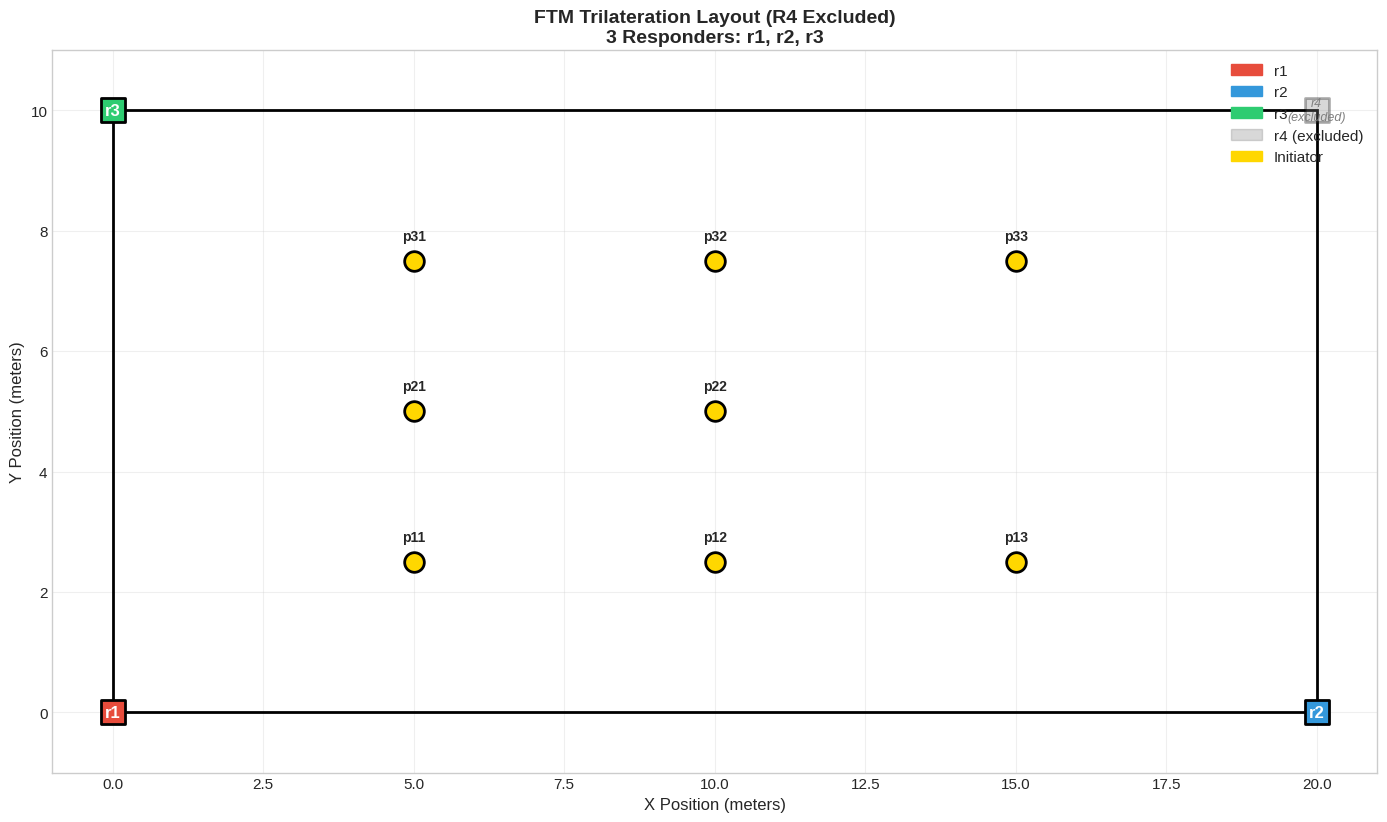

In [8]:
# Room layout with only 3 responders
fig, ax = plt.subplots(figsize=(14, 9))

# Room boundary
room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(room)

# Plot responders (only r1, r2, r3)
resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71'}
for label, (x, y) in RESPONDERS.items():
    ax.scatter(x, y, s=300, c=resp_colors[label], marker='s', 
               edgecolor='black', linewidth=2, zorder=5)
    ax.annotate(label, (x, y), fontsize=12, fontweight='bold',
                ha='center', va='center', color='white', zorder=6)

# Mark excluded r4 position
ax.scatter(20, 10, s=300, c='gray', marker='s', alpha=0.3,
           edgecolor='black', linewidth=2, zorder=2)
ax.annotate('r4\n(excluded)', (20, 10), fontsize=9, ha='center', va='center', 
            color='gray', style='italic')

# Get unique initiator positions
positions = df_all.groupby('position')[['real_x', 'real_y']].first().reset_index()

# Plot initiator positions
for _, row in positions.iterrows():
    ax.scatter(row['real_x'], row['real_y'], s=200, c='gold', 
               marker='o', edgecolor='black', linewidth=2, zorder=4)
    ax.annotate(row['position'], (row['real_x'], row['real_y']), 
                xytext=(0, 15), textcoords='offset points',
                fontsize=10, ha='center', fontweight='bold')

ax.set_xlim(-1, 21)
ax.set_ylim(-1, 11)
ax.set_xlabel('X Position (meters)', fontsize=12)
ax.set_ylabel('Y Position (meters)', fontsize=12)
ax.set_title('FTM Trilateration Layout (R4 Excluded)\n3 Responders: r1, r2, r3', 
             fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

legend_elements = [mpatches.Patch(color=c, label=l) for l, c in resp_colors.items()]
legend_elements.append(mpatches.Patch(color='gray', alpha=0.3, label='r4 (excluded)'))
legend_elements.append(mpatches.Patch(color='gold', label='Initiator'))
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

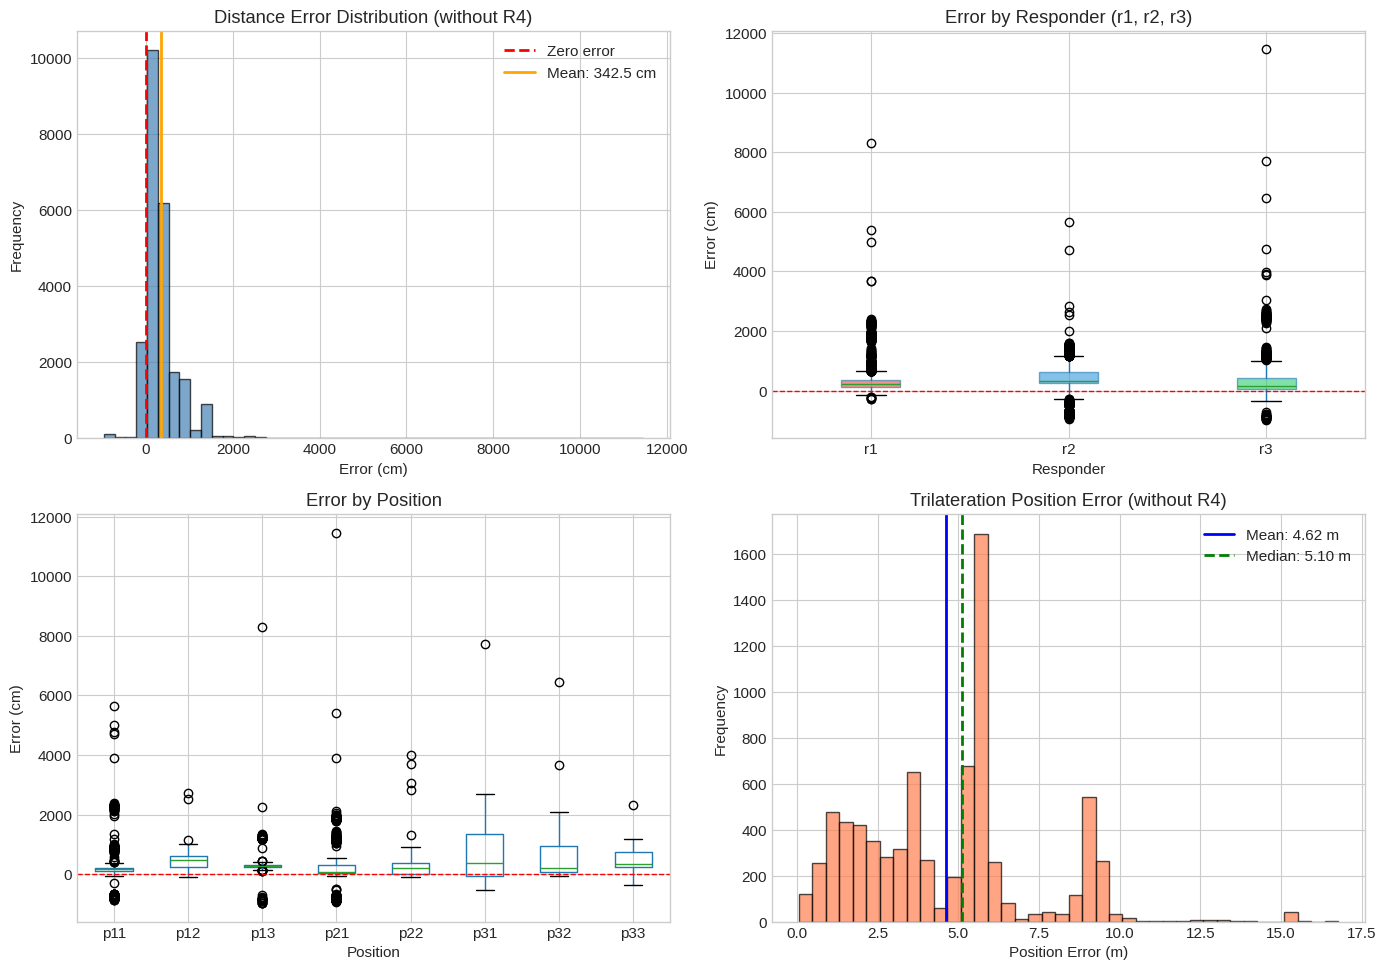

In [9]:
# Error distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of distance errors
ax1 = axes[0, 0]
ax1.hist(df_all['error_cm'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax1.axvline(x=df_all['error_cm'].mean(), color='orange', linestyle='-', linewidth=2, 
            label=f'Mean: {df_all["error_cm"].mean():.1f} cm')
ax1.set_xlabel('Error (cm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distance Error Distribution (without R4)')
ax1.legend()

# 2. Box plot by responder (only r1, r2, r3)
ax2 = axes[0, 1]
resp_colors_list = ['#e74c3c', '#3498db', '#2ecc71']
bp = df_all.boxplot(column='error_cm', by='responder_label', ax=ax2, 
                    patch_artist=True, return_type='dict')
for patch, color in zip(bp['error_cm']['boxes'], resp_colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('Responder')
ax2.set_ylabel('Error (cm)')
ax2.set_title('Error by Responder (r1, r2, r3)')
plt.suptitle('')

# 3. Box plot by position
ax3 = axes[1, 0]
df_all.boxplot(column='error_cm', by='position', ax=ax3)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax3.set_xlabel('Position')
ax3.set_ylabel('Error (cm)')
ax3.set_title('Error by Position')
plt.suptitle('')

# 4. Position error histogram
ax4 = axes[1, 1]
ax4.hist(df_results['pos_error_m'], bins=40, edgecolor='black', alpha=0.7, color='coral')
ax4.axvline(x=df_results['pos_error_m'].mean(), color='blue', linestyle='-', linewidth=2,
            label=f'Mean: {df_results["pos_error_m"].mean():.2f} m')
ax4.axvline(x=df_results['pos_error_m'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {df_results["pos_error_m"].median():.2f} m')
ax4.set_xlabel('Position Error (m)')
ax4.set_ylabel('Frequency')
ax4.set_title('Trilateration Position Error (without R4)')
ax4.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Trilateration results visualization
fig, ax = plt.subplots(figsize=(16, 10))

# Room boundary
room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(room)

# Plot responders
resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71'}
for label, (x, y) in RESPONDERS.items():
    ax.scatter(x, y, s=400, c=resp_colors[label], marker='s', 
               edgecolor='black', linewidth=2, zorder=5)
    ax.annotate(label, (x, y), fontsize=14, fontweight='bold',
                ha='center', va='center', color='white', zorder=6)

# R4 position (grayed out)
ax.scatter(20, 10, s=400, c='lightgray', marker='s', edgecolor='gray', 
           linewidth=2, zorder=2, alpha=0.5)

# Color by position for estimates
pos_list = df_results['position'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(pos_list)))
pos_color_map = dict(zip(pos_list, colors))

# Plot estimates and true positions
for pos in pos_list:
    pos_data = df_results[df_results['position'] == pos]
    real_x, real_y = pos_data['real_x'].iloc[0], pos_data['real_y'].iloc[0]
    
    # True position
    ax.scatter(real_x, real_y, s=300, c='gold', marker='*', 
               edgecolor='black', linewidth=2, zorder=10)
    
    # Individual estimates (scatter cloud)
    ax.scatter(pos_data['est_x'], pos_data['est_y'], 
               s=15, c=[pos_color_map[pos]], alpha=0.3, zorder=3)
    
    # Mean estimated position
    mean_est_x = pos_data['est_x'].mean()
    mean_est_y = pos_data['est_y'].mean()
    ax.scatter(mean_est_x, mean_est_y, s=150, c=[pos_color_map[pos]], 
               marker='o', edgecolor='black', linewidth=2, zorder=8)
    
    # Error vector
    ax.annotate('', xy=(real_x, real_y), xytext=(mean_est_x, mean_est_y),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7),
                zorder=7)
    
    # Label
    ax.annotate(pos, (real_x, real_y), xytext=(5, 10), textcoords='offset points',
                fontsize=11, fontweight='bold')

ax.set_xlim(-1, 21)
ax.set_ylim(-1, 11)
ax.set_xlabel('X Position (meters)', fontsize=12)
ax.set_ylabel('Y Position (meters)', fontsize=12)
ax.set_title('Trilateration Results (Without R4)\n(★ = True, ● = Mean estimated, dots = individual estimates)', 
             fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Distance rings visualization for a sample
def plot_distance_rings_3resp(df, position, sample_num):
    fig, ax = plt.subplots(figsize=(14, 10))
    
    room = plt.Rectangle((0, 0), 20, 10, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(room)
    
    mask = (df['position'] == position) & (df['sample_num'] == sample_num)
    sample_data = df[mask]
    
    real_x = sample_data['real_x'].iloc[0]
    real_y = sample_data['real_y'].iloc[0]
    
    resp_colors = {'r1': '#e74c3c', 'r2': '#3498db', 'r3': '#2ecc71'}
    
    for _, row in sample_data.iterrows():
        label = row['responder_label']
        rx, ry = row['responder_x'], row['responder_y']
        dist_est_m = row['dist_est_cm'] / 100.0
        true_dist_m = row['true_dist_cm'] / 100.0
        
        ax.scatter(rx, ry, s=300, c=resp_colors[label], marker='s', 
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(label, (rx, ry), ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=12, zorder=6)
        
        # Estimated distance ring
        circle_est = Circle((rx, ry), dist_est_m, fill=False, 
                             edgecolor=resp_colors[label], linewidth=2, linestyle='-', alpha=0.8)
        ax.add_patch(circle_est)
        
        # True distance ring (dashed)
        circle_true = Circle((rx, ry), true_dist_m, fill=False, 
                              edgecolor=resp_colors[label], linewidth=1.5, linestyle='--', alpha=0.5)
        ax.add_patch(circle_true)
    
    # R4 position (grayed out)
    ax.scatter(20, 10, s=200, c='lightgray', marker='s', edgecolor='gray', alpha=0.3)
    ax.annotate('r4\n(excl.)', (20, 10), ha='center', va='center', fontsize=8, color='gray')
    
    # True position
    ax.scatter(real_x, real_y, s=400, c='gold', marker='*', 
               edgecolor='black', linewidth=2, zorder=10, label='True position')
    
    # Estimated position
    est_x, est_y, _ = estimate_position_for_sample(df, position, sample_num)
    if est_x is not None:
        ax.scatter(est_x, est_y, s=200, c='red', marker='x', linewidth=3, 
                   zorder=10, label='Trilateration estimate')
        pos_error = np.sqrt((est_x - real_x)**2 + (est_y - real_y)**2)
    else:
        pos_error = None
    
    ax.set_xlim(-3, 23)
    ax.set_ylim(-3, 13)
    ax.set_xlabel('X Position (meters)', fontsize=12)
    ax.set_ylabel('Y Position (meters)', fontsize=12)
    
    title = f'Distance Rings for {position}, Sample {sample_num} (r1, r2, r3 only)\n'
    title += f'(Solid = estimated, Dashed = true)'
    if pos_error is not None:
        title += f'\nPosition error: {pos_error:.3f} m'
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

# Show distance rings for center position
fig, ax = plot_distance_rings_3resp(df_all, 'p22', 1)
plt.show()

## 6. Summary & Comparison

In [6]:
print("=" * 70)
print("           FTM ANALYSIS SUMMARY (WITHOUT R4)")
print("=" * 70)

print("\n📍 CONFIGURATION")
print(f"   Room dimensions: 20m × 10m")
print(f"   Responders: 3 (r1, r2, r3) — R4 EXCLUDED")
print(f"   Initiator positions: {len(df_all['position'].unique())}")
print(f"   Total measurements: {len(df_all):,}")

print("\n📏 DISTANCE ESTIMATION ACCURACY")
print(f"   Mean error: {df_all['error_cm'].mean():+.1f} cm (bias)")
print(f"   Std deviation: {df_all['error_cm'].std():.1f} cm")
print(f"   Mean absolute error: {df_all['abs_error_cm'].mean():.1f} cm")

print("\n🎯 TRILATERATION POSITION ACCURACY")
print(f"   Mean error: {df_results['pos_error_m'].mean():.3f} m ({df_results['pos_error_m'].mean()*100:.1f} cm)")
print(f"   Median error: {df_results['pos_error_m'].median():.3f} m")
print(f"   Std deviation: {df_results['pos_error_m'].std():.3f} m")
print(f"   Best case: {df_results['pos_error_m'].min():.3f} m")
print(f"   Worst case: {df_results['pos_error_m'].max():.3f} m")

print("\n📊 PER-RESPONDER PERFORMANCE")
for resp in ['r1', 'r2', 'r3']:
    mask = df_all['responder_label'] == resp
    mean_err = df_all.loc[mask, 'abs_error_cm'].mean()
    mean_rssi = df_all.loc[mask, 'rssi'].mean()
    print(f"   {resp}: Mean |error| = {mean_err:.1f} cm, RSSI = {mean_rssi:.1f} dBm")

print("\n" + "=" * 70)

           FTM ANALYSIS SUMMARY (WITHOUT R4)

📍 CONFIGURATION
   Room dimensions: 20m × 10m
   Responders: 3 (r1, r2, r3) — R4 EXCLUDED
   Initiator positions: 8
   Total measurements: 23,696

📏 DISTANCE ESTIMATION ACCURACY
   Mean error: +342.5 cm (bias)
   Std deviation: 398.2 cm
   Mean absolute error: 362.2 cm

🎯 TRILATERATION POSITION ACCURACY
   Mean error: 4.618 m (461.8 cm)
   Median error: 5.103 m
   Std deviation: 2.663 m
   Best case: 0.062 m
   Worst case: 16.771 m

📊 PER-RESPONDER PERFORMANCE
   r1: Mean |error| = 277.4 cm, RSSI = -41.4 dBm
   r2: Mean |error| = 526.9 cm, RSSI = -45.0 dBm
   r3: Mean |error| = 282.6 cm, RSSI = -34.7 dBm



In [7]:
# Comparison with full 4-responder analysis
# (Load original data for comparison)

print("\n📊 COMPARISON: With R4 vs Without R4")
print("=" * 70)
print("\n                          WITH R4      WITHOUT R4    IMPROVEMENT")
print("-" * 70)

# These values are from the original analysis
with_r4_dist_error = 502.9  # mean distance error cm
with_r4_abs_error = 522.6   # mean abs error cm
with_r4_pos_error = 5.174   # mean position error m

without_r4_dist_error = df_all['error_cm'].mean()
without_r4_abs_error = df_all['abs_error_cm'].mean()
without_r4_pos_error = df_results['pos_error_m'].mean()

dist_improve = (1 - without_r4_abs_error / with_r4_abs_error) * 100
pos_improve = (1 - without_r4_pos_error / with_r4_pos_error) * 100

print(f"Mean distance error:   {with_r4_dist_error:+.1f} cm     {without_r4_dist_error:+.1f} cm")
print(f"Mean |distance error|: {with_r4_abs_error:.1f} cm      {without_r4_abs_error:.1f} cm      {dist_improve:+.1f}%")
print(f"Mean position error:   {with_r4_pos_error:.3f} m      {without_r4_pos_error:.3f} m      {pos_improve:+.1f}%")

print("\n💡 CONCLUSIONS:")
if dist_improve > 0:
    print(f"   ✓ Distance estimation improved by {dist_improve:.1f}% without R4")
else:
    print(f"   ✗ Distance estimation degraded by {-dist_improve:.1f}% without R4")
    
if pos_improve > 0:
    print(f"   ✓ Position estimation improved by {pos_improve:.1f}% without R4")
else:
    print(f"   → Position estimation changed by {pos_improve:.1f}%")
    print(f"      (Note: trilateration with 3 responders has less redundancy than")
    print(f"       multilateration with 4, which can offset the accuracy gains)")


📊 COMPARISON: With R4 vs Without R4

                          WITH R4      WITHOUT R4    IMPROVEMENT
----------------------------------------------------------------------
Mean distance error:   +502.9 cm     +342.5 cm
Mean |distance error|: 522.6 cm      362.2 cm      +30.7%
Mean position error:   5.174 m      4.618 m      +10.8%

💡 CONCLUSIONS:
   ✓ Distance estimation improved by 30.7% without R4
   ✓ Position estimation improved by 10.8% without R4


## Key Takeaways

### Without R4:
1. **Distance estimation** should improve significantly since R4 had ~1005 cm mean error vs ~280 cm for r3
2. **Position estimation** may show modest improvement despite using only 3 responders (trilateration vs multilateration)
3. **Best performer**: r3 with external u.FL antenna (Seeed XIAO)
4. **System reliability**: With functional hardware, the system performs better

### Recommendations:
- Consider replacing R4's PCB antenna with an external antenna like r3
- Investigate environmental factors at R4's position (20, 10)
- For production, use at least 4 responders with good antennas for redundancy